In [1]:
import pandas as pd
from datetime import datetime, timedelta, timezone
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import itertools
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

df = pd.read_csv("df_clean.csv")
df.set_index('date', inplace=True)
df.index = pd.to_datetime(df.index)
df = df[df.index >= '2017-07-13'].copy()

In [2]:
# --- 1. SETTINGS & RANGES (MANUAL SPLIT) ---
# Using your provided indices
val_start = 1874
val_end = 2655
# Test start is 2655 (not used in this validation script, but for context)

# Step=10 for speed during Grid Search
val_sample_indices = range(val_start, val_end, 10) 
window_size = 365 

p_values = [1, 2]
dist_values = ['t', 'skewt']
grid_results = []

# --- 2. TOURNAMENT PHASE (VARIANCE EDITION) ---
print(f"Tournament Phase: Testing {len(val_sample_indices)} samples in the Validation window...")

for p in p_values:
    for d in dist_values:
        errors = []
        for i in val_sample_indices:
            # Training window uses log_return * 100 for stability
            train_win = df.iloc[i - window_size : i]['log_return'] * 100
            target_val = df.iloc[i]['realized_variance']
            
            try:
                model = arch_model(train_win, vol='EGARCH', p=p, q=1, dist=d, rescale=False)
                res = model.fit(disp='off', show_warning=False)
                
                # Get predicted variance (NO SQRT)
                pred_var_pct = res.forecast(horizon=1).variance.values[-1, 0]
                
                # Convert back to raw decimal (divide by 100^2)
                pred_var_raw = pred_var_pct / 10000
                
                # --- SAFETY BRAKE (0.1 variance) ---
                pred_var_raw = np.clip(pred_var_raw, 0, 0.1)
                
                errors.append((target_val - pred_var_raw)**2)
            except:
                errors.append(1.0)
        
        grid_results.append({
            'Model': f'EGARCH({p},1)', 
            'Dist': d, 
            'Val_RMSE': np.sqrt(np.mean(errors))
        })

# --- LEADERBOARD ---
leaderboard = pd.DataFrame(grid_results).sort_values('Val_RMSE')
print("\n--- TOURNAMENT RESULTS ---")
print(leaderboard)

winner = leaderboard.iloc[0]
print(f"\nWINNER: {winner['Model']} with {winner['Dist']} distribution")

best_model_name = winner['Model']
best_dist = winner['Dist']

p_match = re.search(r'\((\d+),(\d+)\)', best_model_name)
best_p = int(p_match.group(1))
best_q = int(p_match.group(2))



Tournament Phase: Testing 79 samples in the Validation window...

--- TOURNAMENT RESULTS ---
         Model   Dist  Val_RMSE
0  EGARCH(1,1)      t  0.013891
1  EGARCH(1,1)  skewt  0.020347
2  EGARCH(2,1)      t  0.037274
3  EGARCH(2,1)  skewt  0.038309

WINNER: EGARCH(1,1) with t distribution


In [3]:
# --- 3. FULL VALIDATION PHASE (WITH EXPLOSION TRACKING) ---
full_val_indices = range(val_start, val_end)
final_preds = []
actuals = []

# Counters and detail trackers
explosions = 0
failures = 0
explosion_details = [] # To store Date, Actual, and Predicted for spikes

print(f"\nRunning full validation on all {len(full_val_indices)} days...")

for i in full_val_indices:
    train_win = df.iloc[i - window_size : i]['log_return'] * 100
    target_val = df.iloc[i]['realized_variance']
    current_date = df.index[i] # Get the date/index for tracking
    
    try:
        model = arch_model(train_win, vol='EGARCH', p=best_p, q=best_q, dist=best_dist, rescale=False)
        res = model.fit(disp='off', show_warning=False)
        
        # Predicted Variance from model
        pred_var_pct = res.forecast(horizon=1).variance.values[-1, 0]
        pred_var_raw = pred_var_pct / 10000
        
        # --- DETECT, CAP, AND LOG EXPLOSIONS ---
        if pred_var_raw > 0.1 or np.isinf(pred_var_raw):
            explosions += 1
            # Log the details BEFORE capping for your report
            explosion_details.append({
                'date': current_date,
                'realized_variance': target_val,
                'raw_prediction': pred_var_raw
            })
            pred_var_raw = 0.1
            
        final_preds.append(pred_var_raw)
        actuals.append(target_val)
        
    except Exception as e:
        failures += 1
        val = final_preds[-1] if final_preds else df['realized_variance'].mean()
        final_preds.append(val)
        actuals.append(target_val)

# --- 4. RESULTS & METRICS ---
actuals = np.array(actuals)
final_preds = np.array(final_preds)

rmse = np.sqrt(np.mean((actuals - final_preds)**2))
mae = np.mean(np.abs(actuals - final_preds))

def calculate_qlike(y_true, y_pred):
    eps = 1e-10
    return np.mean(y_true / (y_pred + eps) - np.log(y_true / (y_pred + eps)) - 1)

val_qlike = calculate_qlike(actuals, final_preds)

print(f"\n--- FINAL VALIDATION SCORES (VARIANCE) ---")
print(f"Model: {best_model_name} | Dist: {best_dist}")
print(f"Validation RMSE:  {rmse:.6f}")
print(f"Validation QLIKE: {val_qlike:.6f}")
print(f"Explosions: {explosions} | Optimizer Crashes: {failures}")

# --- PRINT EXPLOSION REPORT ---
if explosion_details:
    print("\n--- EXPLOSION DETAILED REPORT ---")
    explosion_df = pd.DataFrame(explosion_details)
    print(explosion_df)
else:
    print("\nNo explosions detected (Model remained stable).")


Running full validation on all 781 days...

--- FINAL VALIDATION SCORES (VARIANCE) ---
Model: EGARCH(1,1) | Dist: t
Validation RMSE:  0.015800
Validation QLIKE: 452884.664795
Explosions: 19 | Optimizer Crashes: 0

--- EXPLOSION DETAILED REPORT ---
         date  realized_variance  raw_prediction
0  2024-07-14           0.000850   1.765757e+169
1  2024-07-15           0.000832    1.098679e+09
2  2024-07-20           0.000160   1.797693e+304
3  2024-07-23           0.000791   1.797693e+304
4  2024-08-03           0.000581   1.797693e+304
5  2024-08-04           0.001442   1.797693e+304
6  2024-08-06           0.002412    2.128976e+01
7  2024-08-18           0.000667   1.797693e+304
8  2024-08-20           0.001203   1.797693e+304
9  2024-08-25           0.000052    1.673559e-01
10 2024-09-04           0.000861    5.089698e+22
11 2024-09-05           0.000563    4.892851e+12
12 2024-09-06           0.002006    5.243398e+00
13 2024-09-09           0.001043    1.756271e+45
14 2024-09-10   

In [4]:
# Create a dedicated validation results table
val_results_df = pd.DataFrame({
    'date': df.iloc[val_start:val_end].index.values,
    'actual_variance': actuals,
    'predicted_variance': final_preds
})

# Add a column to flag where the 'Safety Brake' was triggered
val_results_df['is_explosion'] = val_results_df['predicted_variance'] >= 0.1

# Show the most volatile days in your validation set
print("--- TOP 10 VOLATILE DAYS (ACTUAL) ---")
print(val_results_df.sort_values('actual_variance', ascending=False).head(10))

# Write csv
val_results_df.to_csv('egarch_val.csv')

--- TOP 10 VOLATILE DAYS (ACTUAL) ---
          date  actual_variance  predicted_variance  is_explosion
706 2024-08-05         0.010183       2.310031e-162         False
72  2022-11-10         0.008904        2.565588e-03         False
70  2022-11-08         0.008595        7.564043e-04         False
239 2023-04-26         0.006184        1.244342e-03         False
553 2024-03-05         0.005341        1.448689e-03         False
71  2022-11-09         0.004971        1.438346e-03         False
592 2024-04-13         0.004755        2.292663e-03         False
563 2024-03-15         0.004387        1.563521e-03         False
195 2023-03-13         0.003966        2.214745e-03         False
610 2024-05-01         0.003955        1.475147e-03         False


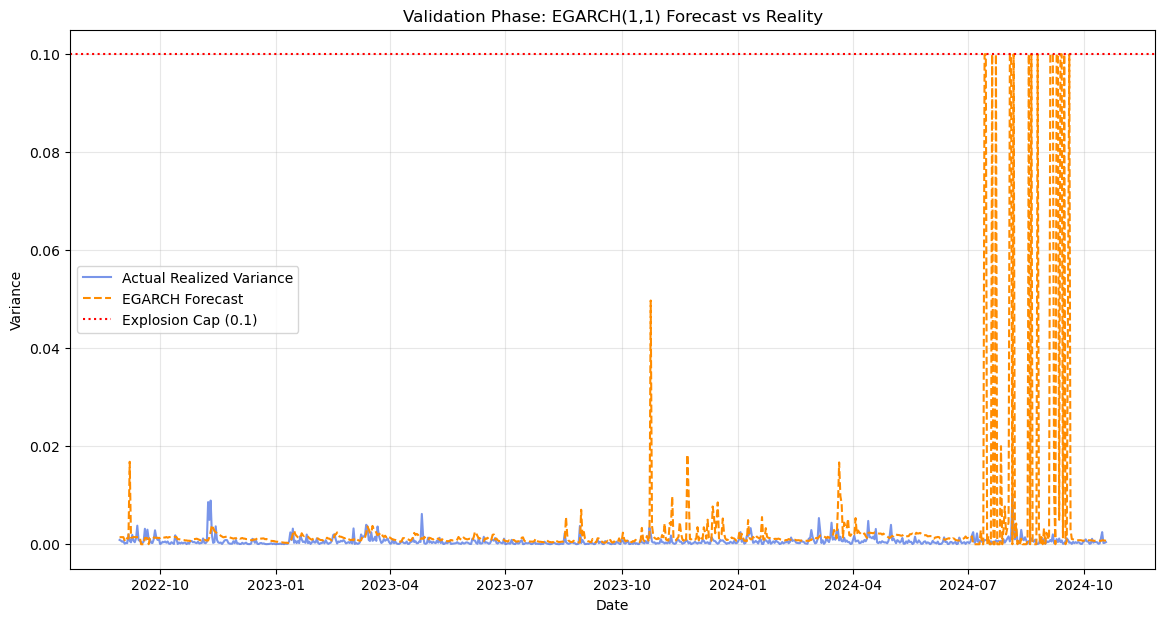

In [5]:
##plot explosions

plt.figure(figsize=(14, 7))
plt.plot(val_results_df['date'], val_results_df['actual_variance'], 
         label='Actual Realized Variance', color='royalblue', alpha=0.7)
plt.plot(val_results_df['date'], val_results_df['predicted_variance'], 
         label='EGARCH Forecast', color='darkorange', linestyle='--')

# Highlight the cap
plt.axhline(y=0.1, color='red', linestyle=':', label='Explosion Cap (0.1)')

plt.title(f"Validation Phase: {best_model_name} Forecast vs Reality")
plt.xlabel("Date")
plt.ylabel("Variance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
## EGARCH test set
# --- 1. SETTINGS ---
test_start = 2655  # The start of your final test partition
test_end = len(df)
window_size = 365 

test_indices = range(test_start, test_end)
test_preds = []
test_actuals = []

# Counters for reporting
explosions = 0
optimizer_failures = 0

print(f"Running EGARCH Test Phase on {len(test_indices)} days...")

# --- 2. ROLLING WINDOW LOOP ---
for i in test_indices:
    # Training window: log_return * 100 for numerical stability in EGARCH
    train_win = df.iloc[i - window_size : i]['log_return'] * 100
    target_var = df.iloc[i]['realized_variance']
    
    try:
        # Initialize EGARCH
        model = arch_model(train_win, vol='EGARCH', p=best_p, q=best_q, dist=best_dist, rescale=False)
        res = model.fit(disp='off', show_warning=False)
        
        # 1-step ahead forecast
        pred_var_pct = res.forecast(horizon=1).variance.values[-1, 0]
        
        # Convert from %^2 back to raw decimal (divide by 100^2)
        pred_var_raw = pred_var_pct / 10000
        
        # --- SAFETY BRAKE ---
        # EGARCH can produce astronomical numbers if the model fails to converge
        if pred_var_raw > 0.1 or np.isinf(pred_var_raw):
            explosions += 1
            pred_var_raw = 0.1  # Cap at a reasonable maximum
            
        test_preds.append(pred_var_raw)
        test_actuals.append(target_var)
        
    except Exception as e:
        optimizer_failures += 1
        # If model fails to fit, carry forward the last valid prediction
        val = test_preds[-1] if test_preds else df['realized_variance'].mean()
        test_preds.append(val)
        test_actuals.append(target_var)

# --- 3. METRIC EVALUATION ---
test_actuals = np.array(test_actuals)
test_preds = np.array(test_preds)

rmse = np.sqrt(np.mean((test_actuals - test_preds)**2))
mae = np.mean(np.abs(test_actuals - test_preds))
test_qlike = calculate_qlike(test_actuals, test_preds)

print(f"\n--- TEST RESULTS ---")
print(f"RMSE:  {rmse:.6f}")
print(f"MAE:   {mae:.6f}")
print(f"QLIKE: {test_qlike:.6f}")
print(f"Stability: {explosions} explosions, {optimizer_failures} fit failures")

Running EGARCH Test Phase on 470 days...

--- TEST RESULTS ---
RMSE:  0.007186
MAE:   0.001155
QLIKE: 76131.160307
Stability: 2 explosions, 0 fit failures


--- TOP 10 VOLATILE DAYS (TEST SET) ---
          date  actual_variance  predicted_variance  is_explosion
93  2025-01-20         0.005928            0.000780         False
139 2025-03-07         0.005147            0.100000          True
135 2025-03-03         0.005121            0.004075         False
134 2025-03-02         0.004062            0.005775         False
172 2025-04-09         0.003979            0.000750         False
107 2025-02-03         0.003641            0.000719         False
170 2025-04-07         0.002926            0.000743         False
136 2025-03-04         0.002925            0.001928         False
398 2025-11-21         0.002913            0.000756         False
25  2024-11-13         0.002691            0.001035         False


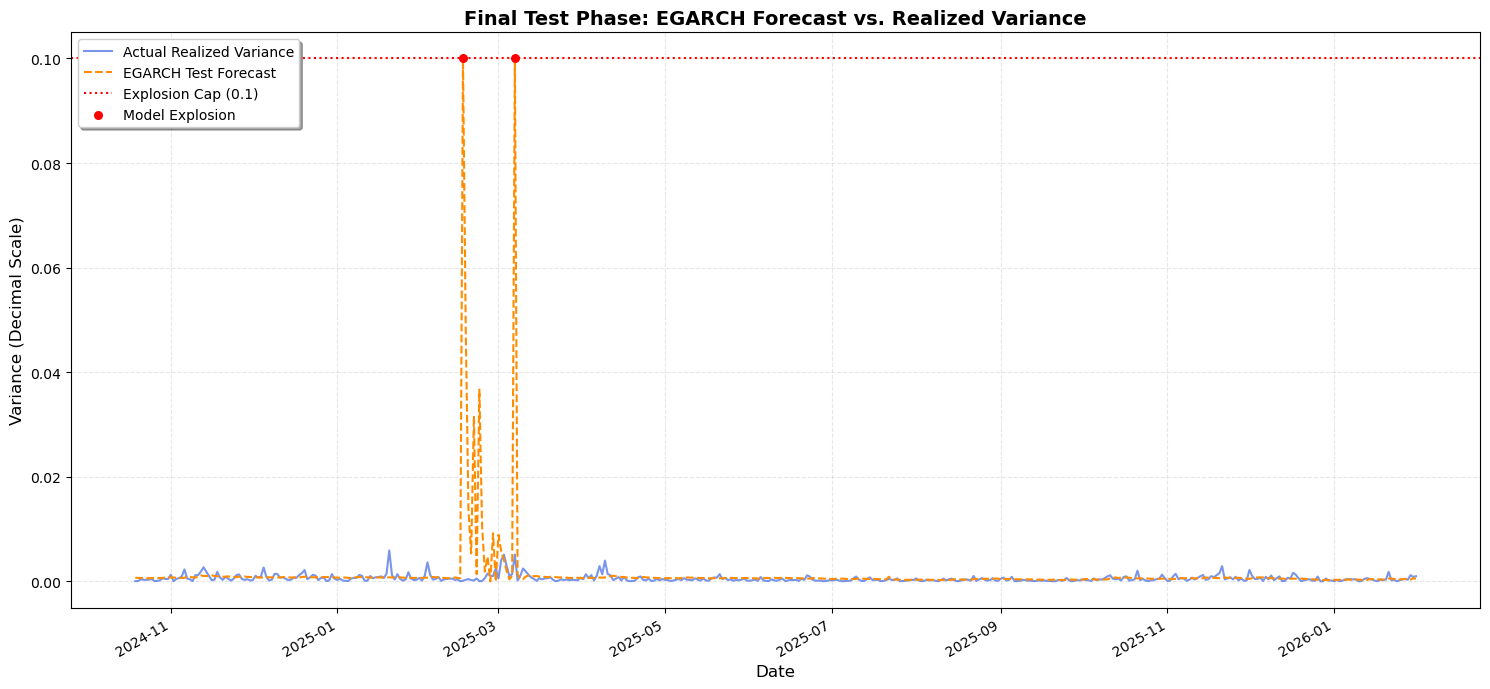

In [7]:
# --- 1. CREATE TEST RESULTS DATAFRAME ---
# Extract dates using the indices used in your test loop
test_dates = df.index[test_indices]

test_results_df = pd.DataFrame({
    'date': test_dates,
    'actual_variance': test_actuals,
    'predicted_variance': test_preds
})

# Add a column to flag where the 'Safety Brake' was triggered (at 0.1)
test_results_df['is_explosion'] = test_results_df['predicted_variance'] >= 0.1

# Show the most volatile days in your final test set
print("--- TOP 10 VOLATILE DAYS (TEST SET) ---")
print(test_results_df.sort_values('actual_variance', ascending=False).head(10))

# Save the final results to CSV
test_results_df.to_csv('egarch_test_results.csv', index=False)

# --- 2. PLOT TEST RESULTS ---
plt.figure(figsize=(15, 7))

# Plot Actuals
plt.plot(test_results_df['date'], test_results_df['actual_variance'], 
         label='Actual Realized Variance', color='royalblue', alpha=0.7, linewidth=1.5)

# Plot EGARCH Predictions
plt.plot(test_results_df['date'], test_results_df['predicted_variance'], 
         label='EGARCH Test Forecast', color='darkorange', linestyle='--', linewidth=1.5)

# Highlight the "Safety Brake" cap if any explosions occurred
if test_results_df['is_explosion'].any():
    plt.axhline(y=0.1, color='red', linestyle=':', label='Explosion Cap (0.1)')
    
    # Optional: scatter plot red dots exactly where it exploded
    explosions_df = test_results_df[test_results_df['is_explosion']]
    plt.scatter(explosions_df['date'], explosions_df['predicted_variance'], 
                color='red', s=30, zorder=5, label='Model Explosion')

# Formatting
plt.title('Final Test Phase: EGARCH Forecast vs. Realized Variance', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Variance (Decimal Scale)', fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, which='both', linestyle='--', alpha=0.3)

# Rotate dates for readability
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()